In [1]:
import sys
from pathlib import Path

# Find the repository root so the top-level 'src' package is importable.
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Could not find project root containing pyproject.toml")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Composition Root — wire dependencies once
from src.engine.risk_snapshot_engine import RiskSnapshotEngine
from src.engine.risk_change_engine import RiskChangeEngine
from src.infrastructure.in_memory_portfolios import InMemoryPortfolioRepository
from src.infrastructure.yfinance_returns import YFinanceReturnsProvider
from src.display.snapshot_renderer import render_snapshot_markdown
from src.display.risk_change_renderer import (
    plot_trailing_portfolio_var,
    render_risk_change_markdown,
)
from IPython.display import Markdown, display

portfolios = InMemoryPortfolioRepository()
returns_provider = YFinanceReturnsProvider()
engine = RiskSnapshotEngine(portfolios, returns_provider)
risk_change_engine = RiskChangeEngine(portfolios, returns_provider)


In [2]:
# ==================
# PARAMETERS
# ==================

DATE = "2025-06-21"
PORTFOLIO = "60/40 Multi-Asset"
PREVIOUS_OBSERVATION_DATE = "2025-05-21"


In [3]:
snapshot = engine.snapshot(PORTFOLIO, DATE)


In [4]:
display(Markdown(render_snapshot_markdown(snapshot)))



## RISK SNAPSHOT — 60/40 Multi-Asset
**21 Jun 2025**

### Portfolio
NAV: £10,000,000

### Portfolio VaR
£102,059 (1.02% of NAV daily)

### Risk Budget
Annualised VaR: 16.2% of NAV  |  Limit: 30% of NAV

██████████░░░░░░░░░░ **54%** utilised
✅

*Limit = 30% annualised VaR at 95% confidence — the maximum loss the
mandate allows in a typical year, set by the Investment Policy Statement.*

### Is This Normal?
▓▓▓▓▓▓▓▓▓▓▓░░░░░░░░░ **56th percentile**

Today's VaR ranks at the 56th percentile of this portfolio's own trailing VaR history since Jan 2019 — about average for this portfolio.

### Decision
→ no action


In [5]:
risk_change = risk_change_engine.compare(
    portfolio_name=PORTFOLIO,
    current_date=DATE,
    previous_observation_date=PREVIOUS_OBSERVATION_DATE,
)


In [6]:
display(Markdown(render_risk_change_markdown(risk_change)))


## RISK CHANGE — 60/40 Multi-Asset
**Current observation:** 20 Jun 2025  
**Previous observation requested:** 21 May 2025 · resolved close: 21 May 2025

### Portfolio-level VaR

| Measure | Previous observation | Current observation | Change |
|---|---:|---:|---:|
| Annualised VaR | 16.51% | 16.20% | -0.31 pp |
| Currency VaR | £104,007 | £102,059 | £-1,948 (-1.87%) |

### Risk-budget
| Measure | Previous observation | Current observation | Change |
|---|---:|---:|---:|
| Risk-budget utilisation | 55.04% | 54.00% | -1.03 pp |
| Breach status | False | False | — |

### Distribution context
| Measure | Previous observation | Current observation | Change |
|---|---:|---:|---:|
| Historical percentile | 58% | 56% | -2 pp |

Requested and resolved dates are shown separately. Values describe portfolio-level VaR; the comparison does not attribute the change or recommend an action.


(<Figure size 1400x500 with 1 Axes>,
 <Axes: title={'center': 'Portfolio-level VaR'}, xlabel='Date', ylabel='Annualised VaR (%)'>)

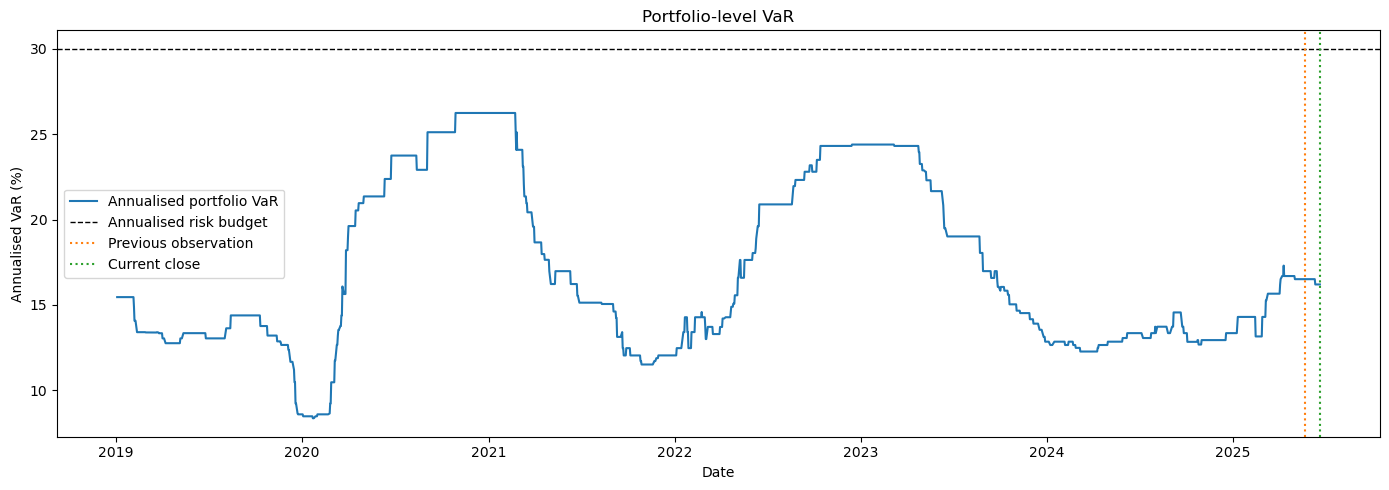

In [7]:
plot_trailing_portfolio_var(
    risk_change.as_of_close_var_history,
    previous_observation_date=risk_change.resolved_previous_observation_date,
    current_date=risk_change.resolved_current_date,
    annualised_risk_budget=risk_change.current.risk_budget_annual_pct,
)
